<a href="https://colab.research.google.com/github/Gabriel-idkw/Customer-Behavior-Prediction/blob/main/03_hierarchical_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Agglomerative (Hierarchical) Clustering
### Grid Search, Dendrogram, Metrics, Visualization

Loads the shared baseline from Notebook 01. Independent of Notebooks 02/04. Exports `models/hierarchical_model.pkl` and `metrics/hierarchical_results.json`.

**Important scaling note:** Agglomerative clustering computes pairwise distances between points, which is `O(n²)` in both time and memory. With ~49,661 customers, a full pairwise distance matrix would need roughly `49661² ≈ 2.5 billion` entries (tens of GB) — infeasible on a standard Colab runtime. This is a well-known limitation of hierarchical clustering, not a shortcut specific to this project. The standard, expected workaround is to fit on a **representative random sample** for the grid search, dendrogram, and metrics, which is what we do below (`SAMPLE_SIZE = 3000`). This matches the guide's own note that Hierarchical Clustering "has no native `.predict()`" and is positioned as a comparison/interpretability method rather than the deployed model.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage

sns.set_style('whitegrid')
RANDOM_STATE = 42
PROJECT_ROOT = '/content/drive/MyDrive/customer-segmentation-ml'


Mounted at /content/drive


## 1. Load the shared baseline and draw the sample

In [2]:
X_df = pd.read_csv(f'{PROJECT_ROOT}/data/preprocessed_rfm_scaled.csv')
raw_df = pd.read_csv(f'{PROJECT_ROOT}/data/customer_features_raw.csv')

SAMPLE_SIZE = 3000
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_df), size=SAMPLE_SIZE, replace=False)

X_full = X_df.drop(columns=['Customer ID']).values
X = X_full[sample_idx]
raw_sample = raw_df.iloc[sample_idx].reset_index(drop=True)

print('Full dataset:', X_full.shape, '| Sample used for hierarchical clustering:', X.shape)


Full dataset: (49661, 16) | Sample used for hierarchical clustering: (3000, 16)


## 2. Grid search

Sweep:
- **Cluster count (K)**: 2–8
- **Linkage**: `ward`, `complete`, `average`
- **Metric**: `euclidean`, `manhattan`

`ward` linkage only supports the `euclidean` metric in scikit-learn — invalid combinations are skipped rather than silently coerced.

In [3]:
K_range = range(2, 9)
linkages = ['ward', 'complete', 'average']
metrics_list = ['euclidean', 'manhattan']

grid_results = []
for k in K_range:
    for link in linkages:
        for metric in metrics_list:
            if link == 'ward' and metric != 'euclidean':
                continue  # invalid combination in scikit-learn
            model = AgglomerativeClustering(n_clusters=k, linkage=link, metric=metric)
            labels = model.fit_predict(X)

            sil = silhouette_score(X, labels)
            db = davies_bouldin_score(X, labels)
            ch = calinski_harabasz_score(X, labels)

            grid_results.append({
                'k': k, 'linkage': link, 'metric': metric,
                'silhouette': float(sil),
                'davies_bouldin': float(db),
                'calinski_harabasz': float(ch),
            })

results_df = pd.DataFrame(grid_results)
results_df.sort_values('silhouette', ascending=False).head(10)


,k,linkage,metric,silhouette,davies_bouldin,calinski_harabasz
3,2,average,euclidean,0.494219,0.896316,54.685823
8,3,average,euclidean,0.475924,0.959754,29.445830
4,2,average,manhattan,0.365774,1.719712,248.868573
9,3,average,manhattan,0.342259,1.711656,150.553533
14,4,average,manhattan,0.334372,1.574058,104.604612
19,5,average,manhattan,0.314828,1.562584,91.094695
24,6,average,manhattan,0.302395,1.559111,75.455579
13,4,average,euclidean,0.292467,1.296467,83.808435
1,2,complete,euclidean,0.292295,1.584930,231.193291
29,7,average,manhattan,0.288759,1.570690,65.894102


## 3. Dendrogram

Ward-linkage dendrogram on the sample — the standard way to visually justify a cut point / cluster count.

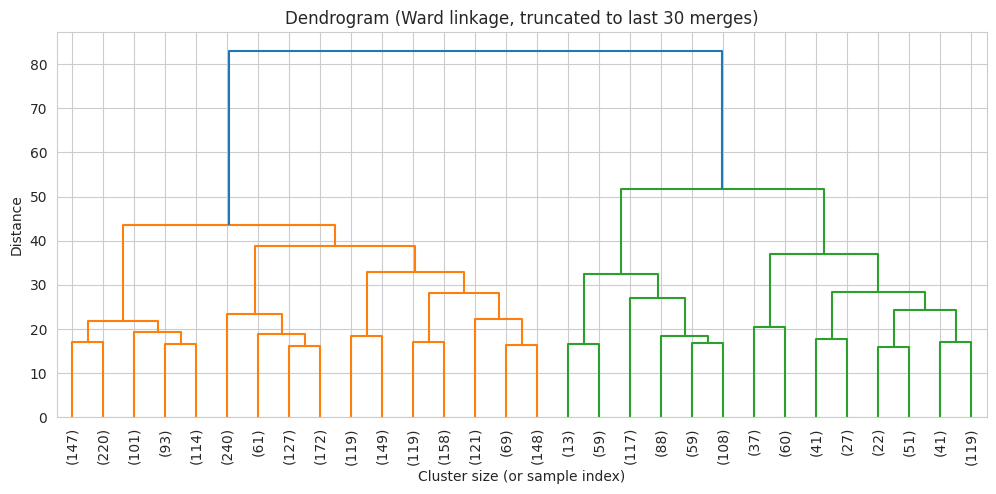

In [4]:
Z = scipy_linkage(X, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title('Dendrogram (Ward linkage, truncated to last 30 merges)')
plt.xlabel('Cluster size (or sample index)')
plt.ylabel('Distance')
plt.show()


## 4. Linkage comparison bar chart

Best silhouette achieved per linkage method (across the K/metric sweep).

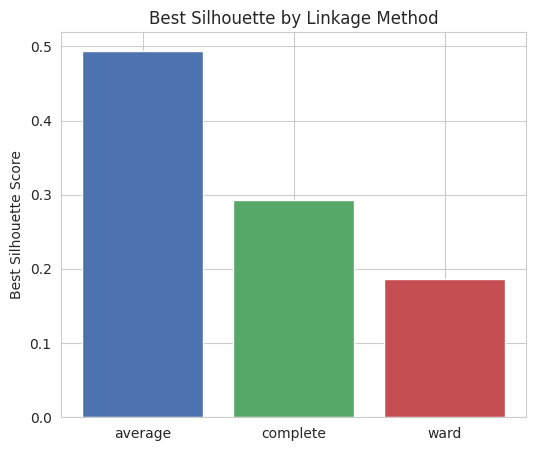

,k,linkage,metric,silhouette,davies_bouldin,calinski_harabasz
3,2,average,euclidean,0.494219,0.896316,54.685823
1,2,complete,euclidean,0.292295,1.584930,231.193291
0,2,ward,euclidean,0.186456,2.403789,449.933124


In [5]:
best_per_linkage = results_df.loc[results_df.groupby('linkage')['silhouette'].idxmax()]

plt.figure(figsize=(6, 5))
plt.bar(best_per_linkage['linkage'], best_per_linkage['silhouette'], color=['#4C72B0', '#55A868', '#C44E52'])
plt.ylabel('Best Silhouette Score')
plt.title('Best Silhouette by Linkage Method')
plt.show()

best_per_linkage


## 5. Pick the best configuration and refit

In [6]:
best_row = results_df.sort_values('silhouette', ascending=False).iloc[0]
BEST_K = int(best_row['k'])
BEST_LINKAGE = best_row['linkage']
BEST_METRIC = best_row['metric']

print('Best config by silhouette:')
print(best_row)

final_model = AgglomerativeClustering(n_clusters=BEST_K, linkage=BEST_LINKAGE, metric=BEST_METRIC)
final_labels = final_model.fit_predict(X)


Best config by silhouette:
k                            2
linkage                average
metric               euclidean
silhouette            0.494219
davies_bouldin        0.896316
calinski_harabasz    54.685823
Name: 3, dtype: object


## 6. 2D PCA scatter

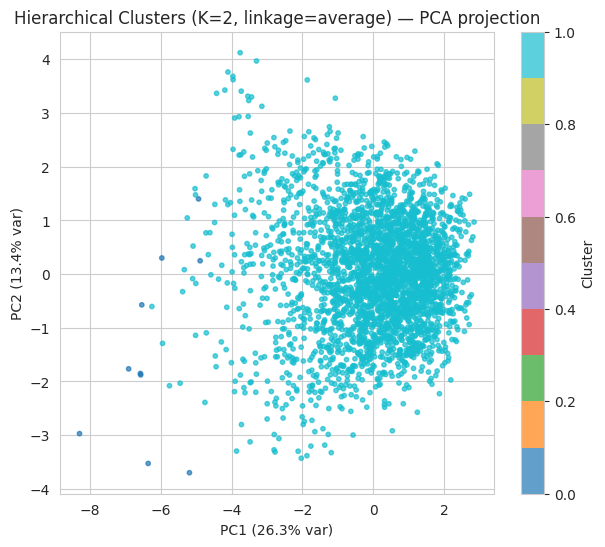

In [7]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, cmap='tab10', s=10, alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.title(f'Hierarchical Clusters (K={BEST_K}, linkage={BEST_LINKAGE}) — PCA projection')
plt.colorbar(scatter, label='Cluster')
plt.show()


## 7. Cluster profile (sample, real units)

In [8]:
profile_df = raw_sample.copy()
profile_df['cluster'] = final_labels
display_cols = ['recency_days', 'frequency', 'monetary_total', 'monetary_avg', 'return_rate', 'churn']
cluster_profile = profile_df.groupby('cluster')[display_cols].mean().round(2)
cluster_profile['n_customers'] = profile_df.groupby('cluster').size()
cluster_profile


,recency_days,frequency,monetary_total,monetary_avg,return_rate,churn,n_customers
cluster,,,,,,,
0,969.10,1.10,1081.70,1121.80,80.00,0.1,10
1,259.88,5.03,13759.31,2744.38,40.21,0.2,2990


## 8. Export

Note in `metrics/hierarchical_results.json` that this model was fit and evaluated on a representative sample, and has no native `.predict()` for new customers — both are expected properties of hierarchical clustering at this scale, documented here rather than hidden.

In [9]:
joblib.dump(final_model, f'{PROJECT_ROOT}/models/hierarchical_model.pkl')

hierarchical_results = {
    'algorithm': 'AgglomerativeClustering',
    'fit_on': f'random sample of {SAMPLE_SIZE} customers (random_state={RANDOM_STATE})',
    'grid_search': grid_results,
    'best_params': {'k': BEST_K, 'linkage': BEST_LINKAGE, 'metric': BEST_METRIC},
    'best_metrics': {
        'silhouette': float(best_row['silhouette']),
        'davies_bouldin': float(best_row['davies_bouldin']),
        'calinski_harabasz': float(best_row['calinski_harabasz']),
    },
    'n_clusters_found': BEST_K,
    'notes': 'No native .predict() on new data; O(n^2) memory means this does not scale to the full customer base, so metrics here are on a sample and are not directly comparable in absolute terms to the full-data KMeans/DBSCAN scores - useful for relative comparison and dendrogram interpretability.',
}
with open(f'{PROJECT_ROOT}/metrics/hierarchical_results.json', 'w') as f:
    json.dump(hierarchical_results, f, indent=2)

print('Saved models/hierarchical_model.pkl and metrics/hierarchical_results.json')
print(json.dumps(hierarchical_results['best_params'], indent=2))
print(json.dumps(hierarchical_results['best_metrics'], indent=2))


Saved models/hierarchical_model.pkl and metrics/hierarchical_results.json
{
  "k": 2,
  "linkage": "average",
  "metric": "euclidean"
}
{
  "silhouette": 0.49421939106193047,
  "davies_bouldin": 0.8963155270447192,
  "calinski_harabasz": 54.68582289252011
}
